In [1]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [2]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "valid" / "images"
test_labels = root / "valid" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


In [3]:
RESIZED_IMG_SIZE=400

In [13]:
import os
import cv2
import numpy as np

def load_detection_data(img_dir, label_dir, img_size=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)):
  images = []
  boxes = [] # Tutaj trafią tylko współrzędne [x, y, w, h]

  file_names = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

  for file_name in file_names:
    # 1. Wczytaj obraz
    img_path = os.path.join(img_dir, file_name.replace('.txt', '.jpg'))
    img = cv2.imread(img_path)
    if img is None: continue
    
    # 2. Wczytaj etykietę (zakładamy format: class x_center y_center w h)
    with open(os.path.join(label_dir, file_name), 'r') as f:
      line = f.readline().split()
      if not line: continue
      
      # Pomijamy klasę (line[0]), bo ten model szuka tylko dłoni ogólnie
      cx, cy, w, h = map(float, line[1:]) 
      
      # Przeliczamy z center (środek) na top-left (lewy górny róg) - łatwiej się to wycina
      x = cx - (w / 2)
      y = cy - (h / 2)
      
      boxes.append([x, y, w, h])

    # 3. Resize obrazu do formatu wejściowego sieci
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    images.append(img / 255.0)

  return np.array(images), np.array(boxes)

# Wczytanie danych
X_train, Y_train = load_detection_data(train_images, train_labels)

X_val, Y_val = load_detection_data(test_images, test_labels)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_locator_model(img_size):
  inputs = layers.Input(shape=(img_size, img_size, 3))
  
  # 1. Konwolucje (Ekstrakcja cech)
  x = layers.Conv2D(16, 3, padding='same', activation='relu')(inputs)
  x = layers.MaxPooling2D()(x)
  
  x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
  x = layers.MaxPooling2D()(x)
  
  x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
  x = layers.MaxPooling2D()(x)

  x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
  x = layers.MaxPooling2D()(x)
  
  # 2. Głowa Regresji (Localization Head)
  # KLUCZOWE: Flatten zamiast GlobalAveragePooling
  x = layers.Flatten()(x)
  
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.2)(x) # Zapobiega przeuczeniu
  
  # 3. Wyjście
  # 4 neurony: [x, y, w, h]
  # Aktywacja 'sigmoid', bo wartości muszą być między 0 a 1
  outputs = layers.Dense(4, activation='sigmoid')(x)
  
  model = models.Model(inputs, outputs)
  return model

detector = build_locator_model(RESIZED_IMG_SIZE)

2026-01-30 22:41:22.506641: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 22:41:23.173745: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 22:41:37.753773: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769809310.243867    1024 gpu_device.cc:2020] Created de

In [ ]:
# Kompilacja
detector.compile(
  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
  loss='mse',      # Minimalizujemy błąd odległości
  metrics=['mae', 'accuracy']  # Średni błąd bezwzględny (dla czytelności)
)

# Callbacks - przydatne narzędzia
callbacks = [
  # Zapisz model tylko, gdy wynik na walidacji się poprawi
  tf.keras.callbacks.ModelCheckpoint(
      'hand_detector_best.keras', 
      save_best_only=True, 
      monitor='val_loss'
  ),
  # Zmniejsz learning rate, gdy sieć przestanie się uczyć
  tf.keras.callbacks.ReduceLROnPlateau(
      monitor='val_loss', 
      factor=0.5, 
      patience=3
  ),
  tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
]

# Start treningu
history = detector.fit(
  X_train, Y_train,
  validation_data=(X_val, Y_val),
  epochs=50,       # Regresja wymaga zazwyczaj więcej epok niż klasyfikacja
  batch_size=16,
  callbacks=callbacks
)

Epoch 1/50


2026-01-30 22:41:53.108959: I external/local_xla/xla/service/service.cc:163] XLA service 0x7403bc005180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-30 22:41:53.108994: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-01-30 22:41:53.166643: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-30 22:41:53.409518: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 7/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2771 - loss: 0.0674 - mae: 0.2149   

I0000 00:00:1769809317.484784    1258 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 385ms/step - accuracy: 0.3739 - loss: 0.0351 - mae: 0.1453 - val_accuracy: 0.2105 - val_loss: 0.0156 - val_mae: 0.1080 - learning_rate: 0.0010
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.4565 - loss: 0.0137 - mae: 0.0957 - val_accuracy: 0.5789 - val_loss: 0.0110 - val_mae: 0.0874 - learning_rate: 0.0010
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4696 - loss: 0.0104 - mae: 0.0817 - val_accuracy: 0.6842 - val_loss: 0.0063 - val_mae: 0.0635 - learning_rate: 0.0010
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5739 - loss: 0.0079 - mae: 0.0694 - val_accuracy: 0.7105 - val_loss: 0.0053 - val_mae: 0.0562 - learning_rate: 0.0010
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5957 - loss: 0.0063 - mae: 0.0615 - val_accuracy: 0.6974 - val_loss: 0.0046 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.6478 - loss: 0.0057 - mae: 0.

In [7]:
score = detector.evaluate(X_val, Y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9211 - loss: 0.0010 - mae: 0.0222


In [ ]:
def crop_hand(image_path, model):
  # 1. Przygotuj obraz
  original_img = cv2.imread(image_path)
  img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
  img_resized = cv2.resize(img, (RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)) / 255.0
  input_tensor = np.expand_dims(img_resized, axis=0)

  # 2. Predykcja ramki
  box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
  
  # 3. Przelicz na piksele
  h_orig, w_orig, _ = original_img.shape
  x = int(box[0] * w_orig)
  y = int(box[1] * h_orig)
  w = int(box[2] * w_orig)
  h = int(box[3] * h_orig)

  # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
  x = max(0, x)
  y = max(0, y)
  
  # 4. Wycięcie (Crop)
  # Dodajemy mały margines (padding), żeby nie uciąć palców
  padding = 20
  crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
  
  return crop, (x, y, w, h)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


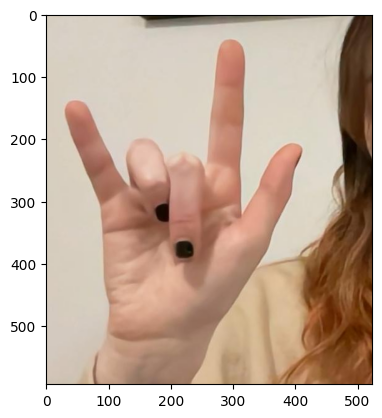

In [ ]:
# Test

import matplotlib.pyplot as plt

cropped_img, coords = crop_hand("./Sign Language Detection/babeczka/test/images/iloveyou_1f4c00c4-7679-11ed-bb1e-1e08bc6ed8a6_jpg.rf.e6b72a4127ff5544f3bd78317ca11b0e.jpg", detector)

if cropped_img.size > 0:
  cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped_img_rgb)